<a href="https://colab.research.google.com/github/rachakondasaivarshini/GAN-PROGRAMS/blob/main/GAN_exp5_prelab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow Version: 2.20.0

Download completed.
Extracting images...


/tmp/ipykernel_921/1414812710.py:73: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


Extraction completed.

Image Folder:
/content/oxford_pets/images
Folder exists: True

Total Images: 7390
Number of Classes: 37

Pet Breeds:
0 -> Abyssinian
1 -> Bengal
2 -> Birman
3 -> Bombay
4 -> British_Shorthair
5 -> Egyptian_Mau
6 -> Maine_Coon
7 -> Persian
8 -> Ragdoll
9 -> Russian_Blue
10 -> Siamese
11 -> Sphynx
12 -> american_bulldog
13 -> american_pit_bull_terrier
14 -> basset_hound
15 -> beagle
16 -> boxer
17 -> chihuahua
18 -> english_cocker_spaniel
19 -> english_setter
20 -> german_shorthaired
21 -> great_pyrenees
22 -> havanese
23 -> japanese_chin
24 -> keeshond
25 -> leonberger
26 -> miniature_pinscher
27 -> newfoundland
28 -> pomeranian
29 -> pug
30 -> saint_bernard
31 -> samoyed
32 -> scottish_terrier
33 -> shiba_inu
34 -> staffordshire_bull_terrier
35 -> wheaten_terrier
36 -> yorkshire_terrier

Images: 7390
Labels: 7390

Training Images: 5912
Testing Images: 1478

Dataset preparation completed.


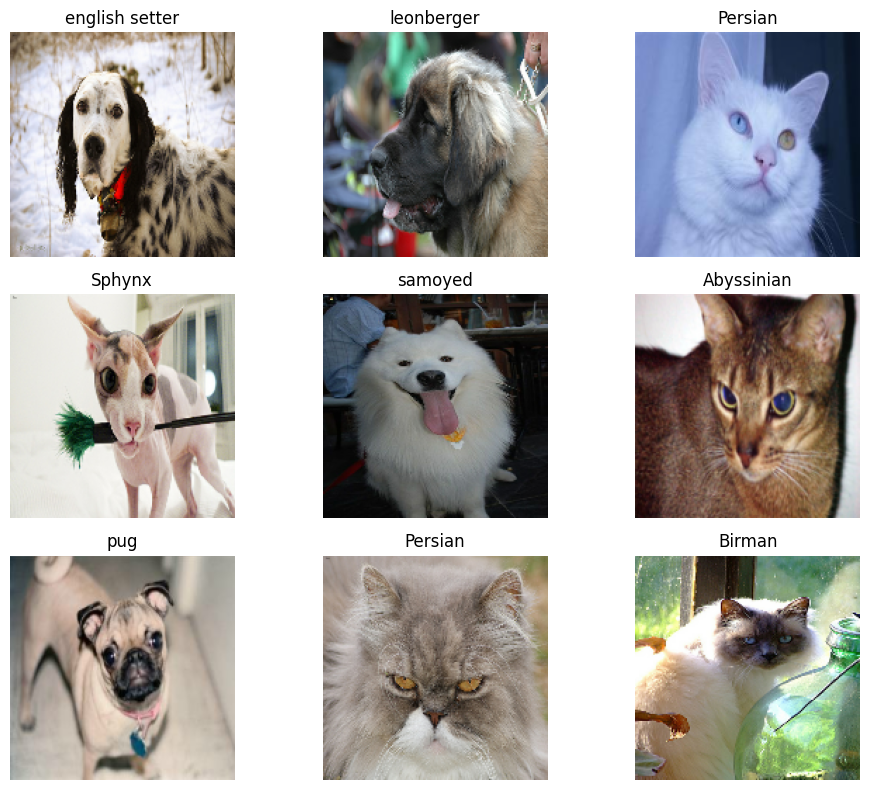


Loading MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MobileNetV2 loaded successfully.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305,381 (8.79 MB)

 Trainable params: 47,397 (185.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Model compiled successfully.

Starting Training...
Epoch 1/5
185/185 ━━━━━━━━━━━━━━━━━━━━ 111s 569ms/step - accuracy: 0.7196 - loss: 1.0186 - val_accuracy: 0.8552 - val_loss: 0.4307
Epoch 2/5
185/185 ━━━━━━━━━━━━━━━━━━━━ 107s 571ms/step - accuracy: 0.8988 - loss: 0.3325 - val_accuracy: 0.8755 - val_loss: 0.3552
Epoch 3/5
185/185 ━━━━━━━━━━━━━━━━━━━━ 108s 579ms/step - accuracy: 0.9340 - loss: 0.2253 - val_accuracy: 0.8850 - val_loss: 0.3286
Epoch 4/5
185/185 ━━━━━━━━━━━━━━━━━━━━ 164s 697ms/step - accuracy: 0.9498 - loss: 0.1697 - val_accuracy: 0.8857 - val_loss: 0.3110
Epoch 5/5
185/185 ━━━━━━━━━━━━━━━━━━━━ 99s 525ms/step - accuracy: 0.9684 - loss: 0.1288 - val_accuracy: 0.8904 - val_loss: 0.3081
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 483ms/step - accuracy: 0.8904 - loss: 0.3081

      MODEL PERFORMANCE
Test Loss: 0.3081
Test Accuracy: 89.04 %


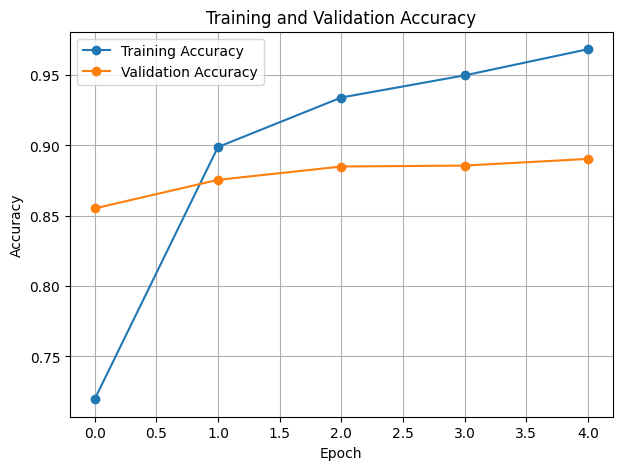

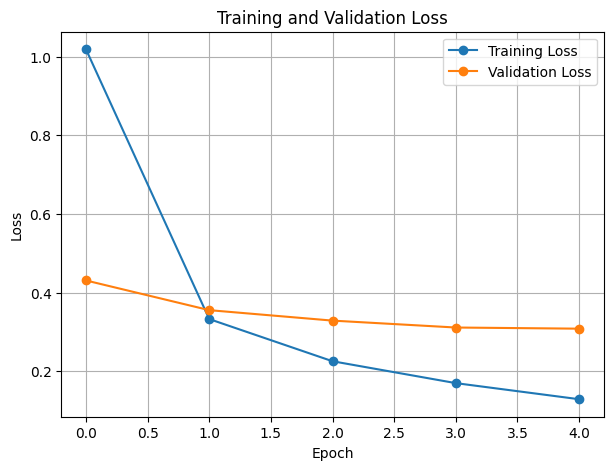

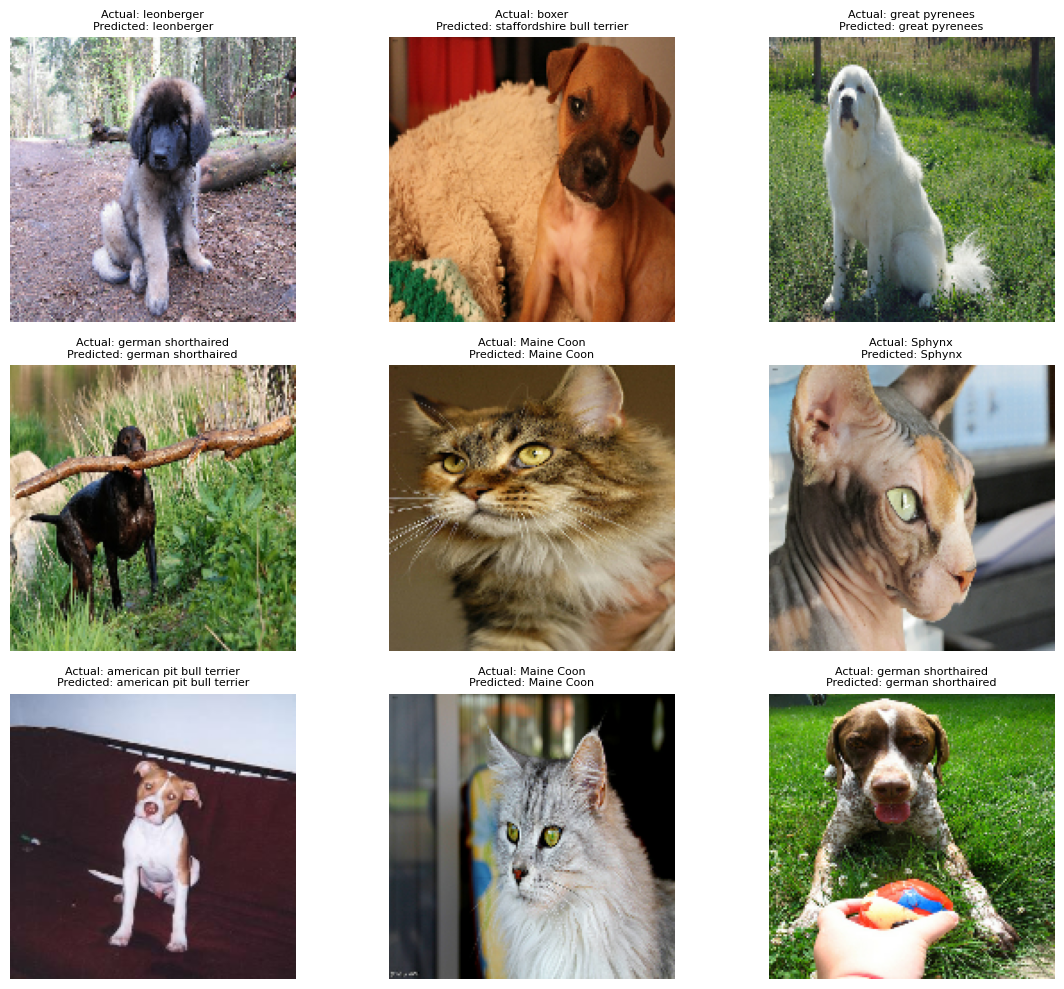


Program completed successfully!


In [1]:
# ============================================================
# LAB-5: EVALUATE THE EFFECTIVENESS OF PRE-TRAINED MODELS
#         USING TRANSFER LEARNING
#
# Model  : MobileNetV2
# Dataset: Oxford-IIIT Pet Dataset
# Classes: 37 Pet Categories
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import os
import tarfile
import urllib.request
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)


# ------------------------------------------------------------
# 2. DOWNLOAD OXFORD-IIIT PET DATASET
# ------------------------------------------------------------

url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"

archive_path = "/content/images.tar.gz"
extract_path = "/content/oxford_pets"

# Create extraction folder
os.makedirs(extract_path, exist_ok=True)

# Download dataset only if it does not already exist
if not os.path.exists(archive_path):

    print("\nDownloading Oxford-IIIT Pet Dataset...")

    urllib.request.urlretrieve(
        url,
        archive_path
    )

    print("Download completed.")

else:

    print("\nDataset archive already downloaded.")


# ------------------------------------------------------------
# 3. EXTRACT DATASET
# ------------------------------------------------------------

image_dir = os.path.join(
    extract_path,
    "images"
)

# Extract only if images folder does not exist
if not os.path.exists(image_dir):

    print("Extracting images...")

    with tarfile.open(
        archive_path,
        "r:gz"
    ) as tar:

        tar.extractall(extract_path)

    print("Extraction completed.")

else:

    print("Images already extracted.")


print("\nImage Folder:")
print(image_dir)

print(
    "Folder exists:",
    os.path.exists(image_dir)
)


# ------------------------------------------------------------
# 4. GET IMAGE FILES
# ------------------------------------------------------------

image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith(".jpg")
]

print("\nTotal Images:", len(image_files))


# ------------------------------------------------------------
# 5. EXTRACT BREED NAME FROM FILENAME
# ------------------------------------------------------------

# Example:
#
# Abyssinian_10.jpg
#       ↓
# Abyssinian
#
# american_bulldog_10.jpg
#       ↓
# american_bulldog


def get_breed(filename):

    name = os.path.splitext(filename)[0]

    breed = name.rsplit("_", 1)[0]

    return breed


# Get all unique breeds

class_names = sorted(
    list(
        set(
            get_breed(f)
            for f in image_files
        )
    )
)

num_classes = len(class_names)

print("Number of Classes:", num_classes)

print("\nPet Breeds:")

for i, name in enumerate(class_names):

    print(
        i,
        "->",
        name
    )


# ------------------------------------------------------------
# 6. CONVERT BREED NAMES INTO NUMBERS
# ------------------------------------------------------------

class_to_index = {
    name: index
    for index, name in enumerate(class_names)
}

paths = []
labels = []

for filename in image_files:

    breed = get_breed(filename)

    paths.append(
        os.path.join(
            image_dir,
            filename
        )
    )

    labels.append(
        class_to_index[breed]
    )


paths = np.array(paths)
labels = np.array(labels)

print("\nImages:", len(paths))
print("Labels:", len(labels))


# ------------------------------------------------------------
# 7. SHUFFLE DATA
# ------------------------------------------------------------

np.random.seed(42)

indices = np.random.permutation(
    len(paths)
)

paths = paths[indices]
labels = labels[indices]


# ------------------------------------------------------------
# 8. TRAIN-TEST SPLIT
# ------------------------------------------------------------

# 80% Training
# 20% Testing

split = int(
    0.8 * len(paths)
)

train_paths = paths[:split]
train_labels = labels[:split]

test_paths = paths[split:]
test_labels = labels[split:]

print(
    "\nTraining Images:",
    len(train_paths)
)

print(
    "Testing Images:",
    len(test_paths)
)


# ------------------------------------------------------------
# 9. IMAGE PREPROCESSING
# ------------------------------------------------------------

IMG_SIZE = 160
BATCH_SIZE = 32


def load_image(path, label):

    # Read image file
    image = tf.io.read_file(path)

    # Decode JPEG image
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    # Resize image
    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    # MobileNetV2 preprocessing
    image = tf.keras.applications.mobilenet_v2.preprocess_input(
        image
    )

    return image, label


# ------------------------------------------------------------
# 10. CREATE TRAINING DATASET
# ------------------------------------------------------------

train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_paths,
        train_labels
    )
)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.shuffle(1000)

train_ds = train_ds.batch(
    BATCH_SIZE
)

train_ds = train_ds.prefetch(
    tf.data.AUTOTUNE
)


# ------------------------------------------------------------
# 11. CREATE TESTING DATASET
# ------------------------------------------------------------

test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_paths,
        test_labels
    )
)

test_ds = test_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.batch(
    BATCH_SIZE
)

test_ds = test_ds.prefetch(
    tf.data.AUTOTUNE
)

print("\nDataset preparation completed.")


# ------------------------------------------------------------
# 12. DISPLAY SAMPLE IMAGES
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 8)
)

for images, batch_labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(
            3,
            3,
            i + 1
        )

        # Convert [-1, 1] back to [0, 1]
        img = (
            images[i].numpy() + 1
        ) / 2

        plt.imshow(img)

        label_number = int(
            batch_labels[i].numpy()
        )

        plt.title(
            class_names[
                label_number
            ].replace("_", " ")
        )

        plt.axis("off")


plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. LOAD PRE-TRAINED MobileNetV2
# ------------------------------------------------------------

print(
    "\nLoading MobileNetV2..."
)

base_model = tf.keras.applications.MobileNetV2(

    input_shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    ),

    # Remove original ImageNet classifier
    include_top=False,

    # Use ImageNet pre-trained weights
    weights="imagenet"
)


# Freeze pre-trained layers
base_model.trainable = False

print(
    "MobileNetV2 loaded successfully."
)


# ------------------------------------------------------------
# 14. CREATE TRANSFER LEARNING MODEL
# ------------------------------------------------------------

model = tf.keras.Sequential([

    # Pre-trained MobileNetV2
    base_model,

    # Convert feature maps into a vector
    tf.keras.layers.GlobalAveragePooling2D(),

    # Reduce overfitting
    tf.keras.layers.Dropout(0.2),

    # New classification layer
    tf.keras.layers.Dense(
        num_classes,
        activation="softmax"
    )
])


# Display model architecture

model.summary()


# ------------------------------------------------------------
# 15. COMPILE MODEL
# ------------------------------------------------------------

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

print(
    "\nModel compiled successfully."
)


# ------------------------------------------------------------
# 16. TRAIN MODEL
# ------------------------------------------------------------

EPOCHS = 5

print(
    "\nStarting Training..."
)

history = model.fit(

    train_ds,

    validation_data=test_ds,

    epochs=EPOCHS
)


# ------------------------------------------------------------
# 17. EVALUATE MODEL
# ------------------------------------------------------------

test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\n==============================")
print("      MODEL PERFORMANCE")
print("==============================")

print(
    "Test Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    round(
        test_accuracy * 100,
        2
    ),
    "%"
)


# ------------------------------------------------------------
# 18. PLOT ACCURACY
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()
plt.grid()

plt.show()


# ------------------------------------------------------------
# 19. PLOT LOSS
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()
plt.grid()

plt.show()


# ------------------------------------------------------------
# 20. PREDICT TEST IMAGES
# ------------------------------------------------------------

plt.figure(
    figsize=(12, 10)
)

for images, batch_labels in test_ds.take(1):

    predictions = model.predict(
        images,
        verbose=0
    )

    for i in range(9):

        plt.subplot(
            3,
            3,
            i + 1
        )

        # Convert image back for display
        img = (
            images[i].numpy() + 1
        ) / 2

        plt.imshow(img)

        # Actual breed
        actual_index = int(
            batch_labels[i].numpy()
        )

        actual_name = class_names[
            actual_index
        ]

        # Predicted breed
        predicted_index = np.argmax(
            predictions[i]
        )

        predicted_name = class_names[
            predicted_index
        ]

        plt.title(
            "Actual: "
            + actual_name.replace("_", " ")
            + "\nPredicted: "
            + predicted_name.replace("_", " "),
            fontsize=8
        )

        plt.axis("off")


plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 21. FINAL MESSAGE
# ------------------------------------------------------------

print(
    "\nProgram completed successfully!"
)